# Sequence Modeling Demo: Sine Wave Prediction with RNN and LSTM

This notebook demonstrates how recurrent neural networks can learn to predict values in a continuous, periodic signal using a simple sine wave.

**Model architecture:**

- Input: sequence of real-valued samples (1 feature per time step)

- Recurrent layer:

  - RNN / LSTM with hidden size = 32 (the size of the internal memory vector)

  - Input sequence length = 50 (i.e., 50 time steps per sample)

  - The recurrent block is applied once per time step — conceptually 50 times — but uses the same parameters across steps

- Output: 1 predicted value per time step (regression)

## RNN

Epoch 20, Loss: 0.0051
Epoch 40, Loss: 0.0022


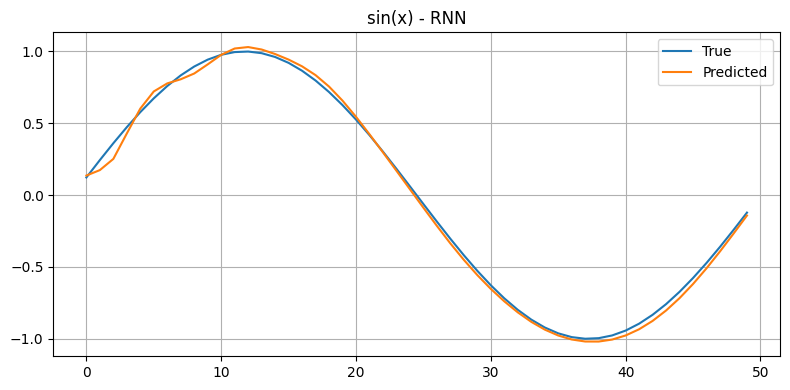

In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Generate sine wave data
def generate_data(seq_length, num_sequences):
    x = np.linspace(0, num_sequences * 2 * np.pi, (seq_length + 1) * num_sequences)
    y = np.sin(x)
    data = []
    for i in range(num_sequences):
        start = i * (seq_length + 1)
        seq_x = y[start:start + seq_length]
        seq_y = y[start + 1:start + seq_length + 1]
        if len(seq_x) == seq_length and len(seq_y) == seq_length:
            data.append((seq_x, seq_y))
    return data


seq_length = 50
num_sequences = 100
data = generate_data(seq_length, num_sequences)
x_data = np.array([x for x, _ in data], dtype=np.float32)
y_data = np.array([y for _, y in data], dtype=np.float32)

x_tensor = torch.tensor(x_data).unsqueeze(-1)
y_tensor = torch.tensor(y_data).unsqueeze(-1)

class SineRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(SineRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out

model = SineRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    output = model(x_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Evaluate and plot
model.eval()
predicted = model(x_tensor).detach().numpy()

plt.figure(figsize=(8, 4))
plt.plot(y_data[0], label="True")
plt.plot(predicted[0], label="Predicted")
plt.title("sin(x) - RNN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## LSTM


Epoch 20, Loss: 0.0146
Epoch 40, Loss: 0.0015


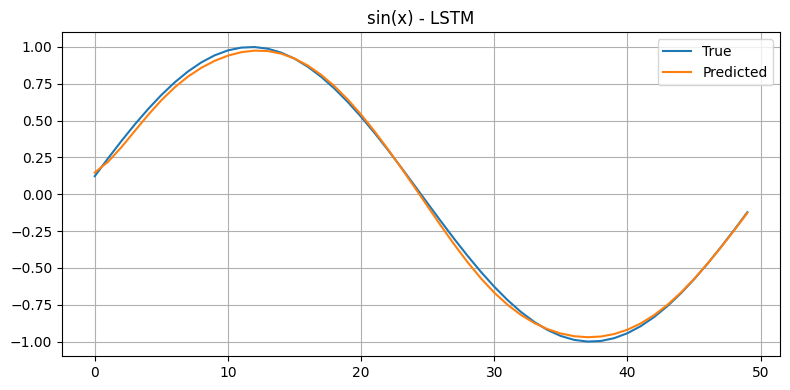

In [15]:
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(SineLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out

model = SineLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    output = model(x_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

model.eval()
predicted = model(x_tensor).detach().numpy()

plt.figure(figsize=(8, 4))
plt.plot(y_data[0], label="True")
plt.plot(predicted[0], label="Predicted")
plt.title("sin(x) - LSTM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
